最新数据日期：2024-01-12
             open   high    low  close      volume
2024-01-08  16.57  17.18  16.40  16.50  17940754.0
2024-01-09  16.30  16.67  15.88  16.17  16787551.0
2024-01-10  16.15  16.42  15.65  16.28  13376237.0
2024-01-11  15.95  16.63  15.61  16.44  15052368.0
2024-01-12  16.30  16.99  16.19  16.19  16338219.0


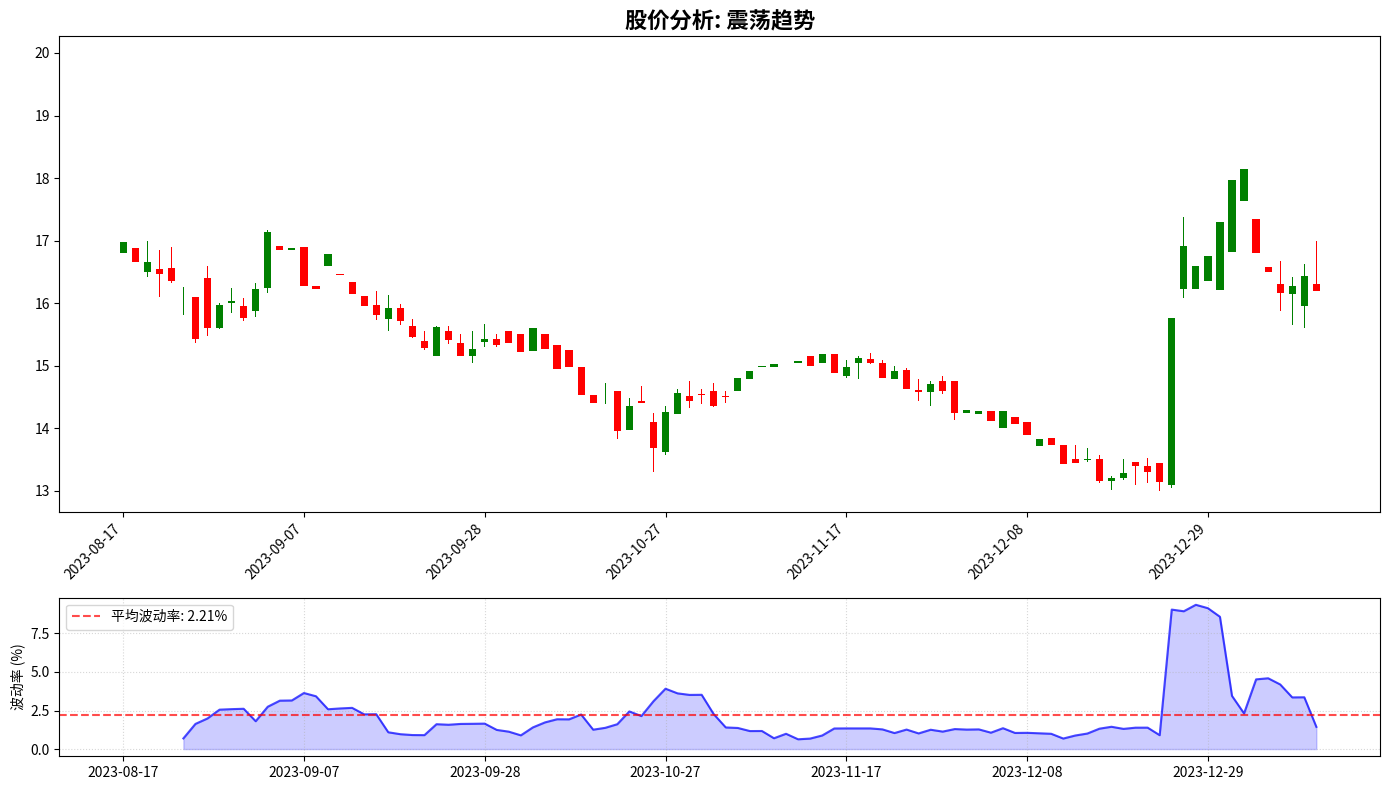


                     股价模式分析报告                     
分析周期: 2023-08-17 至 2024-01-12
趋势方向: 震荡趋势
是否震荡区间: 否


In [6]:
# 完整技术分析看盘程序 v1.0

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib import gridspec
import argparse
import datetime
import numpy as np
from numpy.lib.stride_tricks import sliding_window_view
import pandas as pd
from matplotlib.dates import DateFormatter
from matplotlib.patches import Rectangle
from scipy.signal import find_peaks
from scipy.stats import linregress
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats, signal, cluster
from matplotlib import gridspec
from matplotlib.ticker import FuncFormatter, MaxNLocator

def detect_price_ranges(close_prices, index, window=20, cluster_threshold=1.0, min_range_length=5):
    """
    检测股价区间并识别趋势
    
    参数:
        close_prices: 收盘价序列 (np.array)
        index: 对应的日期索引 (DatetimeIndex)
        window: 趋势检测窗口大小
        cluster_threshold: 聚类边界阈值
        min_range_length: 最小震荡区间长度
        
    返回:
        dict: 包含分析结果
    """
    results = {
        'trend_direction': None, 
        'is_range': False, 
        'support': None, 
        'resistance': None,
        'range_start': None,
        'range_end': None
    }
    
    # 1. 趋势检测（线性回归斜率）
    slopes = []
    for i in range(len(close_prices) - window):
        y = close_prices[i:i+window]
        x = np.arange(len(y))
        slope = stats.linregress(x, y).slope
        slopes.append(slope)
    
    avg_slope = np.mean(slopes)
    
    # 根据斜率判断趋势方向
    if avg_slope > 0.05:
        results['trend_direction'] = '上升趋势'
    elif avg_slope < -0.05:
        results['trend_direction'] = '下降趋势'
    else:
        results['trend_direction'] = '震荡趋势'
    
    # 2. 区间识别（局部极值点）
    max_indices = signal.argrelextrema(close_prices, np.greater, order=5)[0]
    min_indices = signal.argrelextrema(close_prices, np.less, order=5)[0]
    
    resistance = close_prices[max_indices]
    support = close_prices[min_indices]
    
    # 3. 边界聚类分析
    if len(resistance) > 3 and len(support) > 3:
        # 聚类分析找出主要支撑/阻力位
        resistance_centers = cluster.vq.kmeans(resistance.reshape(-1,1), 2)[0]
        support_centers = cluster.vq.kmeans(support.reshape(-1,1), 2)[0]
        
        resistance_range = np.abs(resistance_centers[0] - resistance_centers[1])
        support_range = np.abs(support_centers[0] - support_centers[1])
        
        # 判断是否形成有效区间
        if resistance_range < cluster_threshold and support_range < cluster_threshold:
            support_level = float(min(support_centers))  # 转换为float
            resistance_level = float(max(resistance_centers))  # 转换为float
            
            # 检查区间长度是否足够
            if len(close_prices) >= min_range_length:
                results['is_range'] = True
                results['support'] = support_level
                results['resistance'] = resistance_level
                results['range_start'] = index[0]
                results['range_end'] = index[-1]
    
    return results





def plot_candlestick(ax, df):
    """绘制K线图（使用连续整数索引避免非交易日空白）"""
    # 确定上涨和下跌的K线
    up = df[df['close'] >= df['open']]
    down = df[df['close'] < df['open']]
    
    # 设置K线宽度
    width = 0.6
    width2 = 0.05
    
    # 创建连续整数索引 (0,1,2,...) 代替日期索引
    x = np.arange(len(df))
    
    # 绘制上涨K线（绿色）
    if not up.empty:
        # 获取上涨K线对应的整数索引位置
        up_x = x[df.index.isin(up.index)]
        ax.bar(up_x, up['close'] - up['open'], width, bottom=up['open'], color='g')
        ax.bar(up_x, up['high'] - up['close'], width2, bottom=up['close'], color='g')
        ax.bar(up_x, up['low'] - up['open'], width2, bottom=up['open'], color='g')
    
    # 绘制下跌K线（红色）
    if not down.empty:
        # 获取下跌K线对应的整数索引位置
        down_x = x[df.index.isin(down.index)]
        ax.bar(down_x, down['close'] - down['open'], width, bottom=down['open'], color='r')
        ax.bar(down_x, down['high'] - down['open'], width2, bottom=down['open'], color='r')
        ax.bar(down_x, down['low'] - down['close'], width2, bottom=down['close'], color='r')
    
    return ax

def visualize_analysis(df, analysis):
    """可视化分析结果（使用连续整数索引避免非交易日空白）"""
    fig = plt.figure(figsize=(14, 8))
    gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1])
    
    # 创建连续整数索引 (0,1,2,...)
    x = np.arange(len(df))
    
    # 1. K线图
    ax1 = plt.subplot(gs[0])
    plot_candlestick(ax1, df)
    
    # 设置标题
    title = f"股价分析: {analysis['trend_direction']}"
    if analysis['is_range']:
        # 确保support和resistance是标量值
        support = analysis['support'] if isinstance(analysis['support'], (int, float)) else analysis['support'][0]
        resistance = analysis['resistance'] if isinstance(analysis['resistance'], (int, float)) else analysis['resistance'][0]
        title += f" | 震荡区间: {support:.2f} - {resistance:.2f}"
    ax1.set_title(title, fontsize=16, fontweight='bold')
    
    # 绘制区间边界
    if analysis['is_range']:
        # 确保support和resistance是标量值
        support = analysis['support'] if isinstance(analysis['support'], (int, float)) else analysis['support'][0]
        resistance = analysis['resistance'] if isinstance(analysis['resistance'], (int, float)) else analysis['resistance'][0]
        
        ax1.axhline(y=support, color='blue', linestyle='-', 
                   alpha=0.7, linewidth=2, label=f'支撑位: {support:.2f}')
        ax1.axhline(y=resistance, color='red', linestyle='-', 
                   alpha=0.7, linewidth=2, label=f'阻力位: {resistance:.2f}')
        
        # 标记区间范围 - 将日期转换为整数索引位置
        start_idx = df.index.get_loc(analysis['range_start'])
        end_idx = df.index.get_loc(analysis['range_end'])
        ax1.axvspan(start_idx, end_idx, color='yellow', alpha=0.15)
        
        # 添加区间宽度标注
        range_width = resistance - support
        mid_point = (support + resistance) / 2
        mid_idx = len(df) // 2  # 取中间位置的整数索引
        
        ax1.text(mid_idx, mid_point, f'震荡幅度: {range_width:.2f}', 
                fontsize=12, bbox=dict(facecolor='white', alpha=0.8))
        
        ax1.legend(loc='upper left')
    
    # 2. 价格走势分析
    ax2 = plt.subplot(gs[1], sharex=ax1)
    
    # 计算价格波动率 (使用小写close)
    volatility = df['close'].pct_change().rolling(window=5).std() * 100
    
    # 绘制波动率 - 使用连续整数索引
    ax2.plot(x, volatility, 'b-', alpha=0.7)
    ax2.fill_between(x, 0, volatility, color='blue', alpha=0.2)
    
    # 设置波动率图表
    ax2.set_ylabel('波动率 (%)')
    ax2.grid(True, linestyle=':', alpha=0.5)
    
    # 添加水平参考线
    mean_volatility = volatility.mean()
    ax2.axhline(y=mean_volatility, color='r', linestyle='--', alpha=0.7, 
               label=f'平均波动率: {mean_volatility:.2f}%')
    ax2.legend(loc='upper left')
    
    # 自定义日期格式化函数
    def format_date(idx, pos=None):
        """将整数索引转换为日期字符串"""
        if 0 <= int(idx) < len(df):
            return df.index[int(idx)].strftime('%Y-%m-%d')
        return ''
    
    # 设置x轴格式
    ax1.xaxis.set_major_formatter(FuncFormatter(format_date))
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True, prune='both', nbins=10))
    plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()
    
    # 打印分析报告
    print("\n" + "="*50)
    print("股价模式分析报告".center(50))
    print("="*50)
    print(f"分析周期: {df.index[0].strftime('%Y-%m-%d')} 至 {df.index[-1].strftime('%Y-%m-%d')}")
    print(f"趋势方向: {analysis['trend_direction']}")
    print(f"是否震荡区间: {'是' if analysis['is_range'] else '否'}")
    if analysis['is_range']:
        # 确保support和resistance是标量值
        support = analysis['support'] if isinstance(analysis['support'], (int, float)) else analysis['support'][0]
        resistance = analysis['resistance'] if isinstance(analysis['resistance'], (int, float)) else analysis['resistance'][0]
        print(f"支撑位: {support:.2f}")
        print(f"阻力位: {resistance:.2f}")
        print(f"震荡幅度: {(resistance - support):.2f} ({((resistance - support)/support*100):.2f}%)")
    print("="*50)
    





    

# ================= 主程序 =================
if __name__ == "__main__":
    # MindGo数据获取（需在平台环境中运行）
    # 方法一：使用平台内置数据接口
    from mindgo_api import *
    # 创建命令行参数解析器
    parser = argparse.ArgumentParser(description='Get stock data by code.')
    parser.add_argument(
        '--code',                # 参数名
        type=str,
        default='300505.SZ',     # 默认证券代码
        help='Stock code (default: 300032.SZ)'
    )
    
    # 解析参数时忽略未知参数
    args, unknown = parser.parse_known_args()  # 关键修改
    df = get_price(
        securities=args.code,  # 注意参数名是复数但支持单个代码
        #end_date=datetime.date.today().strftime('%Y%m%d'),  # 结束日期设为今天
        end_date='20240112',  # 结束日期设为今天
        fre_step='1d',           # 日线频率
        fields=['open','high','low','close','volume'],
        fq='pre',                # 前复权
        bar_count=100,           # 获取250根K线
        skip_paused=True         # 跳过停牌日
    ).sort_index()  # 清除证券代码索引层级
   
    # 检查数据样例
    print(f"最新数据日期：{df.index[-1].strftime('%Y-%m-%d')}")
    print(df.tail())
    # 执行分析
    analysis = detect_price_ranges(df['close'].values, df.index, 
                                 window=5, cluster_threshold=1.9)
    
    # 可视化结果
    visualize_analysis(df, analysis)
    
    